# Phase 3: Data Preparation

**CRISP-DM Phase Description:**  
This phase covers all activities to construct the final dataset from the initial raw data. Data preparation tasks are likely to be performed multiple times, and not in any prescribed order. This is typically the longest and most time-consuming phase of the CRISP-DM lifecycle.

---

In [18]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
%matplotlib inline

In [19]:
# Load the dataset from Phase 2 (update the path as needed)
DATA_PATH = "Chicago_Crimes_2012_to_2017.csv"

df = pd.read_csv(DATA_PATH, nrows=50000)

print(f"Loaded dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded dataset: 50000 rows x 23 columns


,Unnamed: 0,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,3,10508693,HZ250496,05/03/2016 11:40:00 PM,013XX S SAWYER AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,True,True,1022,10.0,24.0,29.0,08B,1154907.0,1893681.0,2016,05/10/2016 03:56:50 PM,41.864073,-87.706819,"(41.864073157, -87.706818608)"
1,89,10508695,HZ250409,05/03/2016 09:40:00 PM,061XX S DREXEL AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,RESIDENCE,False,True,313,3.0,20.0,42.0,08B,1183066.0,1864330.0,2016,05/10/2016 03:56:50 PM,41.782922,-87.604363,"(41.782921527, -87.60436317)"
2,197,10508697,HZ250503,05/03/2016 11:31:00 PM,053XX W CHICAGO AVE,0470,PUBLIC PEACE VIOLATION,RECKLESS CONDUCT,STREET,False,False,1524,15.0,37.0,25.0,24,1140789.0,1904819.0,2016,05/10/2016 03:56:50 PM,41.894908,-87.758372,"(41.894908283, -87.758371958)"
3,673,10508698,HZ250424,05/03/2016 10:10:00 PM,049XX W FULTON ST,0460,BATTERY,SIMPLE,SIDEWALK,False,False,1532,15.0,28.0,25.0,08B,1143223.0,1901475.0,2016,05/10/2016 03:56:50 PM,41.885687,-87.749516,"(41.885686845, -87.749515983)"
4,911,10508699,HZ250455,05/03/2016 10:00:00 PM,003XX N LOTUS AVE,0820,THEFT,$500 AND UNDER,RESIDENCE,False,True,1523,15.0,28.0,25.0,06,1139890.0,1901675.0,2016,05/10/2016 03:56:50 PM,41.886297,-87.761751,"(41.886297242, -87.761750709)"


---
### Task 1: Select Data

Decide on the data to be used for analysis. Consider which columns (features) and rows (records) to include or exclude based on:

- **Relevance:** Does this feature contribute to the data mining goal?
- **Data Quality:** Is the quality of this feature sufficient (e.g., too many missing values)?
- **Technical Constraints:** Are there limitations on data volume or specific feature types?

**Output:** A rationale for inclusion/exclusion of data, and the resulting subset.

**Instructions:** Select the columns and rows relevant to your analysis goal. Document your reasoning.

In [20]:
selected_columns = [
    "Primary Type",   # target
    "District",
    "Beat",
    "Ward",
    "Community Area",
    "Latitude",
    "Longitude",
    "Date",
    "Arrest",
    "Domestic"
]

df = df[selected_columns]
df.head()

,Primary Type,District,Beat,Ward,Community Area,Latitude,Longitude,Date,Arrest,Domestic
0,BATTERY,10.0,1022,24.0,29.0,41.864073,-87.706819,05/03/2016 11:40:00 PM,True,True
1,BATTERY,3.0,313,20.0,42.0,41.782922,-87.604363,05/03/2016 09:40:00 PM,False,True
2,PUBLIC PEACE VIOLATION,15.0,1524,37.0,25.0,41.894908,-87.758372,05/03/2016 11:31:00 PM,False,False
3,BATTERY,15.0,1532,28.0,25.0,41.885687,-87.749516,05/03/2016 10:10:00 PM,False,False
4,THEFT,15.0,1523,28.0,25.0,41.886297,-87.761751,05/03/2016 10:00:00 PM,False,True


Irrelevant columns such as IDs and descriptive text fields were removed. Only features relevant to predicting crime type were retained.

In [21]:
# Optional: Filter rows based on specific criteria
# No additional row filtering was applied at this stage.
print("No extra row filtering applied.")
print("Current shape:", df.shape)

No extra row filtering applied.
Current shape: (50000, 10)


---
### Task 2: Clean Data

Raise data quality to the level required by the selected analysis techniques. Cleaning activities include:

- **Handle Missing Values:** Impute missing values (mean, median, mode, forward/backward fill) or remove rows/columns with excessive missing data.
- **Correct Errors:** Fix inaccurate or corrupted data entries.
- **Remove Duplicates:** Eliminate exact or near-duplicate records.
- **Handle Outliers:** Decide how to treat extreme values (keep, cap, transform, or remove).

**Instructions:** Apply appropriate cleaning techniques to address the data quality issues identified in Phase 2, Task 4.

In [22]:
# TODO: Handle missing values.
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_report = missing_report[missing_report["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print("=== Missing Values Report ===")
print(missing_report)

# Impute missing numeric values
df["Latitude"] = df["Latitude"].fillna(df["Latitude"].median())
df["Longitude"] = df["Longitude"].fillna(df["Longitude"].median())
df["Ward"] = df["Ward"].fillna(df["Ward"].mode()[0])
df["Community Area"] = df["Community Area"].fillna(df["Community Area"].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())


=== Missing Values Report ===
                Missing Count  Missing %
Longitude                6253     12.506
Latitude                 6253     12.506
Community Area             15      0.030
Ward                        1      0.002

Missing values after handling:
Primary Type      0
District          0
Beat              0
Ward              0
Community Area    0
Latitude          0
Longitude         0
Date              0
Arrest            0
Domestic          0
dtype: int64


In [23]:
# TODO: Remove duplicate records.
duplicates_before = df.duplicated().sum()
print("Duplicate rows before removal:", duplicates_before)

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()
print("Duplicate rows after removal:", duplicates_after)
print("Shape after removing duplicates:", df.shape)

Duplicate rows before removal: 107
Duplicate rows after removal: 0
Shape after removing duplicates: (49893, 10)


Shape after handling coordinate outliers: (49893, 10)


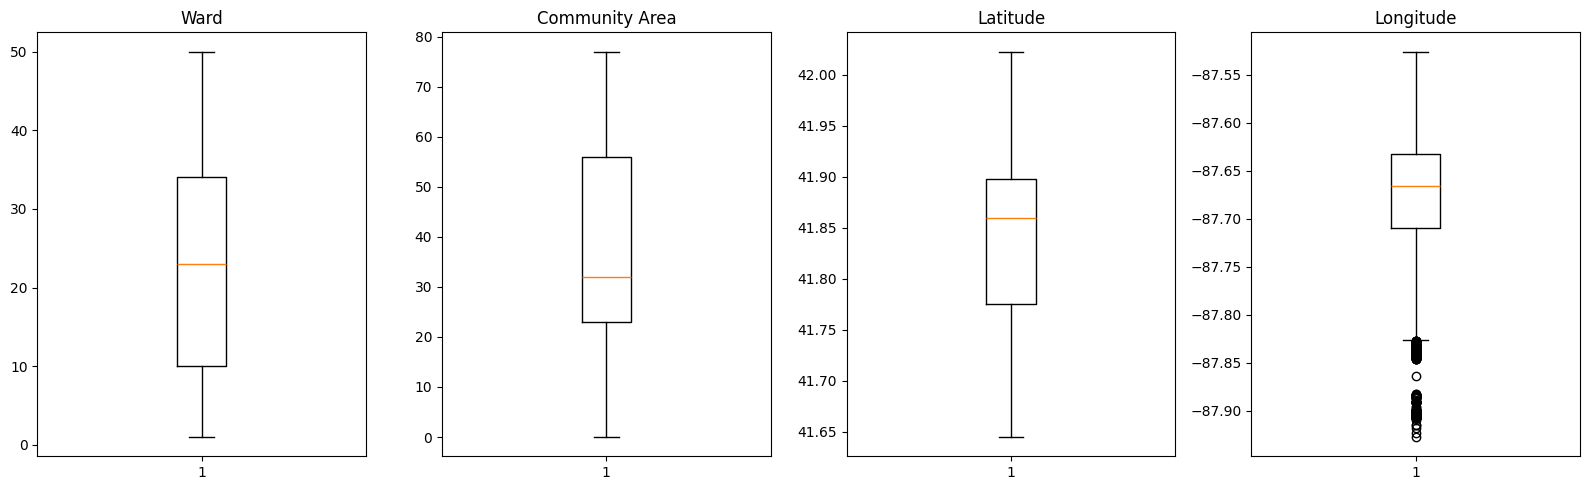

In [24]:
# TODO: Handle outliers.
# Handle coordinate outliers using realistic Chicago bounds
df = df[
    (df["Latitude"].between(41.6, 42.1)) &
    (df["Longitude"].between(-87.95, -87.5))
]

print("Shape after handling coordinate outliers:", df.shape)

selected_cols = ["Ward", "Community Area", "Latitude", "Longitude"]

fig, axes = plt.subplots(1, len(selected_cols), figsize=(4 * len(selected_cols), 5))
for ax, col in zip(axes, selected_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)

plt.tight_layout()
plt.show()

Missing values were removed to improve data quality. Duplicate records were also removed to ensure that repeated entries do not bias the model.

---
### Task 3: Construct Data (Feature Engineering)

This task involves creating new attributes (features) derived from existing ones that may be more useful for modelling. Common techniques include:

- **Derived Attributes:** Create new features from existing ones (e.g., extracting `year`, `month`, `day` from a datetime column; computing `total_spend = price * quantity`).
- **Binning / Discretisation:** Convert continuous variables into categorical bins (e.g., age groups).
- **Encoding Categorical Variables:** Convert categorical features into numerical representations (e.g., one-hot encoding, label encoding).
- **Scaling / Normalisation:** Scale numerical features to a common range (e.g., Min-Max scaling, Standardisation).

**Instructions:** Create new features or transform existing ones to improve model performance.

In [25]:
# TODO: Create derived attributes / new features.
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create temporal features
df["Hour"] = df["Date"].dt.hour
df["Day"] = df["Date"].dt.day_name()
df["Month"] = df["Date"].dt.month

df.head()

C:\Users\meeka\AppData\Local\Temp\ipykernel_10140\1755308514.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


,Primary Type,District,Beat,Ward,Community Area,Latitude,Longitude,Date,Arrest,Domestic,Hour,Day,Month
0,BATTERY,10.0,1022,24.0,29.0,41.864073,-87.706819,2016-05-03 23:40:00,True,True,23,Tuesday,5
1,BATTERY,3.0,313,20.0,42.0,41.782922,-87.604363,2016-05-03 21:40:00,False,True,21,Tuesday,5
2,PUBLIC PEACE VIOLATION,15.0,1524,37.0,25.0,41.894908,-87.758372,2016-05-03 23:31:00,False,False,23,Tuesday,5
3,BATTERY,15.0,1532,28.0,25.0,41.885687,-87.749516,2016-05-03 22:10:00,False,False,22,Tuesday,5
4,THEFT,15.0,1523,28.0,25.0,41.886297,-87.761751,2016-05-03 22:00:00,False,True,22,Tuesday,5


In [26]:
# TODO: Encode categorical variables.

# Drop original Date column after extracting useful features
df = df.drop(columns=["Date"])

# One-hot encode Day
df_encoded = pd.get_dummies(df, columns=["Day"], drop_first=True)

# Encode target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded["Primary Type"] = le.fit_transform(df_encoded["Primary Type"])

print("Encoded dataset shape:", df_encoded.shape)
df_encoded.head()

Encoded dataset shape: (49893, 17)


,Primary Type,District,Beat,Ward,Community Area,Latitude,Longitude,Arrest,Domestic,Hour,Month,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,2,10.0,1022,24.0,29.0,41.864073,-87.706819,True,True,23,5,False,False,False,False,True,False
1,2,3.0,313,20.0,42.0,41.782922,-87.604363,False,True,21,5,False,False,False,False,True,False
2,25,15.0,1524,37.0,25.0,41.894908,-87.758372,False,False,23,5,False,False,False,False,True,False
3,2,15.0,1532,28.0,25.0,41.885687,-87.749516,False,False,22,5,False,False,False,False,True,False
4,29,15.0,1523,28.0,25.0,41.886297,-87.761751,False,True,22,5,False,False,False,False,True,False


Temporal features such as hour, day, and month were extracted from the date column to capture time-based crime patterns. The weekday feature was one-hot encoded, and the target variable was label encoded to prepare the dataset for machine learning.

In [27]:
# TODO: Scale / normalise numerical features if required.

from sklearn.preprocessing import StandardScaler

df_prepared = df_encoded.copy()

cols_to_scale = [
    "District",
    "Beat",
    "Ward",
    "Community Area",
    "Latitude",
    "Longitude",
    "Hour",
    "Month"
]

scaler = StandardScaler()
df_prepared[cols_to_scale] = scaler.fit_transform(df_prepared[cols_to_scale])

print("Scaled numerical columns:", cols_to_scale)
df_prepared.head()

Scaled numerical columns: ['District', 'Beat', 'Ward', 'Community Area', 'Latitude', 'Longitude', 'Hour', 'Month']


,Primary Type,District,Beat,Ward,Community Area,Latitude,Longitude,Arrest,Domestic,Hour,Month,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,2,-0.175841,-0.177317,0.082296,-0.388973,0.254171,-0.626245,True,True,1.503107,0.503378,False,False,False,False,True,False
1,2,-1.182804,-1.196081,-0.206752,0.220859,-0.754929,1.184976,False,True,1.200278,0.503378,False,False,False,False,True,False
2,25,0.543418,0.544009,1.021704,-0.576614,0.637598,-1.537612,False,False,1.503107,0.503378,False,False,False,False,True,False
3,2,0.543418,0.555504,0.371345,-0.576614,0.522932,-1.381055,False,False,1.351693,0.503378,False,False,False,False,True,False
4,29,0.543418,0.542572,0.371345,-0.576614,0.530522,-1.597342,False,True,1.351693,0.503378,False,False,False,False,True,False


---
### Task 4: Integrate Data

If your project uses multiple data sources, this task involves merging or combining them into a single, unified dataset. Activities include:

- **Merging Tables:** Join datasets on common keys (e.g., using `pd.merge()`).
- **Appending Records:** Concatenate datasets with the same structure (e.g., using `pd.concat()`).
- **Aggregation:** Summarise data at a different level of granularity.

**Instructions:** If using multiple data sources, merge or concatenate them below. If your project uses a single dataset, document that here and proceed to the next task.

In [28]:
# TODO: Integrate data from multiple sources (if applicable).
# Single-source project: no external dataset was merged in this phase
df_integrated = df_prepared.copy()

print("Single-source dataset used; no merge required.")
print("Integrated dataset shape:", df_integrated.shape)

Single-source dataset used; no merge required.
Integrated dataset shape: (49893, 17)


In [29]:
# Optional: Verify the integrated data
df_integrated.head()

,Primary Type,District,Beat,Ward,Community Area,Latitude,Longitude,Arrest,Domestic,Hour,Month,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,2,-0.175841,-0.177317,0.082296,-0.388973,0.254171,-0.626245,True,True,1.503107,0.503378,False,False,False,False,True,False
1,2,-1.182804,-1.196081,-0.206752,0.220859,-0.754929,1.184976,False,True,1.200278,0.503378,False,False,False,False,True,False
2,25,0.543418,0.544009,1.021704,-0.576614,0.637598,-1.537612,False,False,1.503107,0.503378,False,False,False,False,True,False
3,2,0.543418,0.555504,0.371345,-0.576614,0.522932,-1.381055,False,False,1.351693,0.503378,False,False,False,False,True,False
4,29,0.543418,0.542572,0.371345,-0.576614,0.530522,-1.597342,False,True,1.351693,0.503378,False,False,False,False,True,False


---
### Task 5: Format Data

This final preparation task ensures the data is in the correct format for the modelling tools. Activities include:

- **Data Type Conversions:** Ensure all columns have appropriate data types (e.g., numeric, datetime, categorical).
- **Column Reordering:** Arrange columns in a logical order (e.g., features first, target last).
- **Renaming:** Give columns clear, descriptive names.
- **Saving the Prepared Dataset:** Export the final, clean dataset for use in subsequent phases.

**Instructions:** Apply any final formatting changes and save the prepared dataset.

In [30]:
# TODO: Apply final formatting — data types, column order, renaming.
df_final = df_integrated.copy()

# Move target column to the end
target_col = "Primary Type"
feature_cols = [col for col in df_final.columns if col != target_col]
df_final = df_final[feature_cols + [target_col]]

# Standardize column names
df_final.columns = [col.lower().replace(" ", "_") for col in df_final.columns]

df_final.head()

,district,beat,ward,community_area,latitude,longitude,arrest,domestic,hour,month,day_monday,day_saturday,day_sunday,day_thursday,day_tuesday,day_wednesday,primary_type
0,-0.175841,-0.177317,0.082296,-0.388973,0.254171,-0.626245,True,True,1.503107,0.503378,False,False,False,False,True,False,2
1,-1.182804,-1.196081,-0.206752,0.220859,-0.754929,1.184976,False,True,1.200278,0.503378,False,False,False,False,True,False,2
2,0.543418,0.544009,1.021704,-0.576614,0.637598,-1.537612,False,False,1.503107,0.503378,False,False,False,False,True,False,25
3,0.543418,0.555504,0.371345,-0.576614,0.522932,-1.381055,False,False,1.351693,0.503378,False,False,False,False,True,False,2
4,0.543418,0.542572,0.371345,-0.576614,0.530522,-1.597342,False,True,1.351693,0.503378,False,False,False,False,True,False,29


In [31]:
# TODO: Verify the final prepared dataset.

print("=" * 60)
print("FINAL PREPARED DATASET SUMMARY")
print("=" * 60)
print(f"Shape: {df_final.shape}")
print(f"Missing values: {df_final.isnull().sum().sum()}")
print(f"Duplicates: {df_final.duplicated().sum()}")

print("\nColumn types:")
print(df_final.dtypes)

df_final.head()

FINAL PREPARED DATASET SUMMARY
Shape: (49893, 17)
Missing values: 0
Duplicates: 184

Column types:
district          float64
beat              float64
ward              float64
community_area    float64
latitude          float64
longitude         float64
arrest               bool
domestic             bool
hour              float64
month             float64
day_monday           bool
day_saturday         bool
day_sunday           bool
day_thursday         bool
day_tuesday          bool
day_wednesday        bool
primary_type        int64
dtype: object


,district,beat,ward,community_area,latitude,longitude,arrest,domestic,hour,month,day_monday,day_saturday,day_sunday,day_thursday,day_tuesday,day_wednesday,primary_type
0,-0.175841,-0.177317,0.082296,-0.388973,0.254171,-0.626245,True,True,1.503107,0.503378,False,False,False,False,True,False,2
1,-1.182804,-1.196081,-0.206752,0.220859,-0.754929,1.184976,False,True,1.200278,0.503378,False,False,False,False,True,False,2
2,0.543418,0.544009,1.021704,-0.576614,0.637598,-1.537612,False,False,1.503107,0.503378,False,False,False,False,True,False,25
3,0.543418,0.555504,0.371345,-0.576614,0.522932,-1.381055,False,False,1.351693,0.503378,False,False,False,False,True,False,2
4,0.543418,0.542572,0.371345,-0.576614,0.530522,-1.597342,False,True,1.351693,0.503378,False,False,False,False,True,False,29


In [32]:
# TODO: Save the prepared dataset for use in Phase 4 (Modelling).

OUTPUT_PATH = "crime_data_prepared.csv"
df_final.to_csv(OUTPUT_PATH, index=False)

print(f"Prepared dataset saved to: {OUTPUT_PATH}")

Prepared dataset saved to: crime_data_prepared.csv
